In [1]:
import pandas as pd
import numpy as np
import sqlite3
import time
import re 
import os

from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
print("Libraries imported successfully")


Libraries imported successfully


In [2]:
SOURCE_FILE = Path("Amazon Sale Report.xlsx")
DB_FILE = Path("inventory.db")
REJECTED_FILE = Path("rejected_records.csv")

print("Current folder :")
print(Path.cwd())
print("\n Files available : ")
for file in Path.cwd().iterdir():
    print(file.name)

Current folder :
C:\DataSet\ecommerce

 Files available : 
.ipynb_checkpoints
Amazon Sale Report.csv.zip
amazon_data
Exploratory Data Analysis.ipynb
inventory.db
sales_analysis.db


In [3]:
import zipfile
ZIP_FILE = Path("Amazon Sale Report.csv.zip")
if not ZIP_FILE.exists():
    raise FileNotError(f"ZIP file not Found{ZIP_FILE.resolve()}")
with zipfile.ZipFile(ZIP_FILE,"r") as zip_ref:
    zip_ref.extractall("amazon_data")
    print("ZIP extracted successfully! ")
    print("\n Extracted files: ")
    for file in Path ("amazon_data").iterdir():
        print(file.name)

ZIP extracted successfully! 

 Extracted files: 
Amazon Sale Report.csv


In [4]:
from pathlib import Path
print("current folder :",Path.cwd())
print("\n CSV files found anywhere in current project : ")
for file in Path.cwd().rglob("*.csv"):
    print(file)

current folder : C:\DataSet\ecommerce

 CSV files found anywhere in current project : 
C:\DataSet\ecommerce\amazon_data\Amazon Sale Report.csv


In [5]:
SOURCE_FILE = Path("amazon_data/Amazon Sale Report.csv")
if not SOURCE_FILE.exists():
    raise FileNotFoundError(f"CSV file not found:{SOURCE_FILE.resolve()}")
    print("CSV file found successfully!")
    print("File :",SOURCE_FILE.resolve())

In [6]:
start_time = time.perf_counter()
raw_df = pd.read_csv(SOURCE_FILE,low_memory = False)
read_time = time.perf_counter() - start_time
print("="*50)
print("CSV LOADED SUCCESSFULLY")
print("="*50)
print(f"Rows : {len(raw_df):,}")
print(f"Columns : {len(raw_df.columns)}")
print(f"Load Time : {read_time :.4f} seconds")
print(f"Memory :" f"{raw_df.memory_usage(deep = True).sum() / 1024**2:.2f} MB")
display(raw_df.head())

CSV LOADED SUCCESSFULLY
Rows : 128,975
Columns : 24
Load Time : 1.5155 seconds
Memory :173.69 MB


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [7]:
# ================
# Data Profiling
#=================

print("="* 60)
print("DATASET PROFILE")
print("+"* 60)
print(f"total Rows : {raw_df.shape[0]:,}")
print("\nColumn Names : ")
for i,col in enumerate(raw_df.columns,1):
    print(f"{i}.{col}")
    print("\n Data Types :")
    display(raw_df.dtypes.to_frame("Data Type"))
    print("\nMissing Values:")
    missing = raw_df.isna().sum().sort_values(ascending = False)
    display(missing.to_frame("Missing Count"))
    print("\nDuplicate Rows : ")
    print(raw_df.duplicated().sum())

    print("\nSample Records;")
    display(raw_df.head(10))

DATASET PROFILE
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
total Rows : 128,975

Column Names : 
1.index

 Data Types :


,Data Type
index,int64
Order ID,str
Date,str
Status,str
Fulfilment,str
Sales Channel,str
ship-service-level,str
Style,str
SKU,str
Category,str



Missing Values:


,Missing Count
fulfilled-by,89698
promotion-ids,49153
Unnamed: 22,49050
currency,7795
Amount,7795
Courier Status,6872
ship-country,33
ship-city,33
ship-state,33
ship-postal-code,33



Duplicate Rows : 
0

Sample Records;


...

,Data Type
index,int64
Order ID,str
Date,str
Status,str
Fulfilment,str
Sales Channel,str
ship-service-level,str
Style,str
SKU,str
Category,str



Missing Values:


,Missing Count
fulfilled-by,89698
promotion-ids,49153
Unnamed: 22,49050
currency,7795
Amount,7795
Courier Status,6872
ship-country,33
ship-city,33
ship-state,33
ship-postal-code,33



Duplicate Rows : 
0

Sample Records;


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,B08B3XF5MH,Shipped,1,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


In [8]:
# =======================
# UNIQUE VALUE PROFILING
# =======================

profile = pd.DataFrame({
    "Column" : raw_df.columns,"data_Type":
    raw_df.dtypes.astype(str).values,"Missing_Count":
    raw_df.isna().sum().values,"Unique_Count":
    raw_df.nunique(dropna = True).values
})
profile["Missing_%"] = (
    profile["Missing_Count"] / len(raw_df)*100).round(2)
display(profile)


,Column,data_Type,Missing_Count,Unique_Count,Missing_%
0,index,int64,0,128975,0.00
1,Order ID,str,0,120378,0.00
2,Date,str,0,91,0.00
3,Status,str,0,13,0.00
4,Fulfilment,str,0,2,0.00
5,Sales Channel,str,0,2,0.00
6,ship-service-level,str,0,2,0.00
7,Style,str,0,1377,0.00
8,SKU,str,0,7195,0.00
9,Category,str,0,9,0.00


In [9]:
# ======================
# STANDARDIZE COLUMN NAMES
# ======================

df = raw_df.copy()

df.columns = df.columns.str.strip()
df.columns = (df.columns.str.lower().str.strip().str.replace(" ","_").str.replace("-","_").str.replace("/","_"))

print("Standardized Columns : ")
print(df.columns.tolist())

Standardized Columns : 
['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'style', 'sku', 'category', 'size', 'asin', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids', 'b2b', 'fulfilled_by', 'unnamed:_22']


In [10]:
# ================================
# REMOVE UNNNAMED / EMPTY COLUMNS
# ================================

unnamed_cols = [
        i for i in df.columns
        if i.startswith("unnamed")
]
print("Columns to remove : ")
print(unnamed_cols)
df.drop(columns = unnamed_cols,errors = "ignore")
print("\nRemaining columns : ")
print(df.columns.tolist())


Columns to remove : 
['unnamed:_22']

Remaining columns : 
['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'style', 'sku', 'category', 'size', 'asin', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids', 'b2b', 'fulfilled_by', 'unnamed:_22']


In [11]:
# =========================
# REMOVING EMPTY COLUMNS
# =========================
clean_df = df.copy()
clean_df = clean_df.loc[ :, ~clean_df.columns.astype(str).str.contains('unnamed',case = False, na = False)]

clean_df = clean_df.drop_duplicates()
print("shape : ",clean_df.shape)
print("Columns :")
print(clean_df.columns.tolist())

shape :  (128975, 23)
Columns :
['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'style', 'sku', 'category', 'size', 'asin', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids', 'b2b', 'fulfilled_by']


In [12]:
# =================================
# DUPLICATE RECORD VALIDATION 
# =================================

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found : {duplicate_count :,}")
if duplicate_count > 0:
    duplicate_df = df[df.duplicated(keep = False)].copy()
    display(duplicate_df.head(10))
else :
    print("No duplicate rows found : ")

Duplicate rows found : 0
No duplicate rows found : 


In [13]:
# =============================
# REQUIRED COLUMN VALIDATION 
# =============================

required_columns = ["order_id","date","status","fulfilment","sales_channel","sku","category","qty","amount","ship_city","ship_state"]
missing_required = [
        col for col in required_columns 
            if col not in df.columns
]
if missing_required :
    print("Missing required columns : ")
else :
    print("All required columns are available ")

All required columns are available 


In [14]:
# =========================
# DATA TYPE TRANSFORMATION 
# =========================

df["date"] = pd.to_datetime(df["date"],errors = "coerce")
df["qty"] = pd.to_numeric(df["qty"],errors = "coerce")
df["amount"] = pd.to_numeric(df["amount"],errors = "coerce")
if "ship_postal_code" in df.columns:
    df["ship_postal_code"] = (
        df["ship_postal_code"].astype("string").str.strip())
    print("Data types transfromed successfully")
    display(df.dtypes.to_frame("Data Type"))

    
        
    

Data types transfromed successfully


C:\Users\akhil\AppData\Local\Temp\ipykernel_3068\4183369191.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"],errors = "coerce")


,Data Type
index,int64
order_id,str
date,datetime64[us]
status,str
fulfilment,str
sales_channel,str
ship_service_level,str
style,str
sku,str
category,str


In [15]:
# ==============================
# DATA QUALITY VALIDATION 
# =============================
validation = pd.DataFrame(index=df.index)
validation["missing_order_id"] = (df["order_id"].isna() | (df["order_id"].astype("string").str.strip() == ""))
validation["invalid_date"] = df["date"].isna()
validation["invalid_qty"] = (df["qty"].isna() | (df["qty"] <= 0))
validation["reject_record"] = validation.any(axis = 1)
print("="*50)
print("validation summary")
print("="*50)
for column in validation.columns:
    print(f"{column :<25}:"f"{validation[column].sum():,}")

    print(f"\n Total records to reject : "f"{validation['reject_record'].sum() :,}")


    

validation summary
missing_order_id         :0

 Total records to reject : 12,807
invalid_date             :0

 Total records to reject : 12,807
invalid_qty              :12,807

 Total records to reject : 12,807
reject_record            :12,807

 Total records to reject : 12,807


In [16]:
# =================================
# REJECT BAD RECORDS 
# =================================

rejected_df = df[validation["reject_record"]].copy()
clean_df = df[~validation["reject_record"]].copy()

def get_rejection_reason(row):
    reasons = []
    if row["missing_order_id"]:
        reasons.append("missing_order_id : ")
    if row["invalid_qty"]:
            reasons.append("invalid_date : ")
    if row["invalid_amount"]:
             reasons.append("invalid_amount : ")
    return ";".join(reasons)
        
    if len(rejected_df)>0:
        rejected_validation = validation[validation["reject_record"]].copy()
    
        rejected_df["rejection_reason"] = (rejected_validation.apply(
            get_rejection_reason, axis=1).values)
        
        rejected_df.to_csv(
            REJECTED_FILE,index=False)
print("="*50)
print("Data Validation Completed")
print("="*50)

print(f"Total records: {len(df):,}")
print(f"Valid records : {len(clean_df):,}")
print(f"Rejected records : {len(rejected_df):,}")
        
print("="*50)
if len(rejected_df) > 0:
    print("Rejected records saved to : ")
    print(REJECTED_FILE.resolve())

Data Validation Completed
Total records: 128,975
Valid records : 116,168
Rejected records : 12,807
Rejected records saved to : 
C:\DataSet\ecommerce\rejected_records.csv


In [17]:
# ====================================
# FINAL CLEAN DATA CHECK
# ====================================
print("="*60)
print("Clean DataSet")
print("="*60)

print(f"Rows{len(clean_df)}:,")
print(f"Columns{len(clean_df.columns)}")
print(f"Duplicates : " f"{clean_df.duplicated().sum():,}")
print("\n Missing Values : ")
display(
    clean_df.isna().sum().sort_values(ascending = False).to_frame("Missing Count")
)
display(clean_df.head())

Clean DataSet
Rows116168:,
Columns24
Duplicates : 0

 Missing Values : 


,Missing Count
fulfilled_by,83763
unnamed:_22,43984
promotion_ids,36686
currency,124
amount,124
ship_country,28
ship_city,28
ship_postal_code,28
ship_state,28
ship_service_level,0


,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


In [18]:
# ========================
# CREATE SQLITE DATABASE
# ========================
DB_FILE = Path("inventory.db")
conn = sqlite3.connect(DB_FILE)
print("SQLite database connected successfully!")
print("Database: ",DB_FILE.resolve())

SQLite database connected successfully!
Database:  C:\DataSet\ecommerce\inventory.db


In [19]:
# ============================
# LOAD DATA INTO SQLITE
# ============================

load_start = time.perf_counter()
clean_df.to_sql("amazon_sales",conn,if_exists = "replace",index = False)
load_time = time.perf_counter() - load_start
print("="* 60)
print("DATABASE LAOD COMPLETED")
print("="* 60)
print(f"Records loaded : {len(clean_df):,}")
print(f"Load time {load_time :4f} seconds")
print(f"Database{DB_FILE.resolve()}")
print(f"Table amazon_sales")

DATABASE LAOD COMPLETED
Records loaded : 116,168
Load time 1.988495 seconds
DatabaseC:\DataSet\ecommerce\inventory.db
Table amazon_sales


In [20]:
# ===========================
# DATABASE VALIDATION 
# ===========================
cursor = conn.cursor()
cursor.execute("Select count(*) from amazon_sales")
db_count = cursor.fetchone()[0]
print("Database Validation")
print("="*50)
print(f"Source clean records : {len(clean_df):,}")
print(f"Database records : {db_count:,}")

if db_count == len(clean_df):
    print("STATUS : PASS")
else :
    print("STATUS : FAIL")

Database Validation
Source clean records : 116,168
Database records : 116,168
STATUS : PASS


In [21]:
# ============================
# SQL DATA CHECK
# ============================
query = """ 
    Select order_id,date,status,category,qty,amount,ship_state from amazon_sales limit 10;
    """
result = pd.read_sql_query(query,conn)
display(result)

,order_id,date,status,category,qty,amount,ship_state
0,171-9198151-1101146,2022-04-30 00:00:00,Shipped - Delivered to Buyer,kurta,1,406.0,KARNATAKA
1,404-0687676-7273146,2022-04-30 00:00:00,Shipped,kurta,1,329.0,MAHARASHTRA
2,407-1069790-7240320,2022-04-30 00:00:00,Shipped,Top,1,574.0,TAMIL NADU
3,404-1490984-4578765,2022-04-30 00:00:00,Shipped,Set,1,824.0,UTTAR PRADESH
4,408-5748499-6859555,2022-04-30 00:00:00,Shipped,Set,1,653.0,CHANDIGARH
5,406-7807733-3785945,2022-04-30 00:00:00,Shipped - Delivered to Buyer,kurta,1,399.0,TELANGANA
6,402-4393761-0311520,2022-04-30 00:00:00,Shipped,kurta,1,363.0,TAMIL NADU
7,407-5633625-6970741,2022-04-30 00:00:00,Shipped,kurta,1,685.0,TAMIL NADU
8,171-4638481-6326716,2022-04-30 00:00:00,Shipped,kurta,1,364.0,UTTAR PRADESH
9,405-5513694-8146768,2022-04-30 00:00:00,Shipped - Delivered to Buyer,kurta,1,399.0,MAHARASHTRA


In [22]:
# ===================
# TOTAL SALES
# ===================
query = """
    select round(sum(amount),2) as total_sales from amazon_sales where amount is not null """
display(pd.read_sql_query(query,conn))

,total_sales
0,75402506.0


In [23]:
# ===============
# Category Performance
# ===============

query = """
Select category,count(*) as orders,sum(qty) as units_sold, round(sum(amount),2) as revenue
from amazon_sales group by category order by revenue desc; """

display(pd.read_sql_query(query,conn))

,category,orders,units_sold,revenue
0,Set,45150,45289,37662424.0
1,kurta,44814,45045,20452141.0
2,Western Dress,13898,13943,10629096.0
3,Top,9870,9903,5203733.0
4,Ethnic Dress,1050,1053,760711.0
5,Blouse,841,863,434751.0
6,Bottom,394,398,140226.0
7,Saree,148,152,118509.0
8,Dupatta,3,3,915.0


In [24]:
# =========================
# State - Wise Sales
# =========================

query = """ 
select ship_state,count(*) as orders, round(sum(amount),2)as revenue 
from amazon_sales where amount is not null group by ship_state order by revenue desc limit 15; """
display(pd.read_sql_query(query,conn))

,ship_state,orders,revenue
0,MAHARASHTRA,20273,12864511.0
1,KARNATAKA,15844,10153100.0
2,TELANGANA,10208,6642955.0
3,UTTAR PRADESH,9462,6494393.0
4,TAMIL NADU,10345,6241913.0
5,DELHI,6144,4080019.0
6,KERALA,5793,3618505.0
7,WEST BENGAL,5301,3357170.0
8,ANDHRA PRADESH,4795,3049151.0
9,HARYANA,4043,2791446.0


In [25]:
# ======================
# Order Status Analysis
# ======================
query = """
select status,count(*) as order_count,round(count(*)*100.0 / (select count(*) from amazon_sales),2) as percentage from amazon_sales 
group by status order by order_count desc;"""
display(pd.read_sql_query(query,conn))

,status,order_count,percentage
0,Shipped,77711,66.90
1,Shipped - Delivered to Buyer,28761,24.76
2,Cancelled,5631,4.85
3,Shipped - Returned to Seller,1950,1.68
4,Shipped - Picked Up,973,0.84
5,Pending,656,0.56
6,Pending - Waiting for Pick Up,281,0.24
7,Shipped - Returning to Seller,145,0.12
8,Shipped - Out for Delivery,35,0.03
9,Shipped - Rejected by Buyer,11,0.01


In [26]:
# ================================
# ETL PIPELINE SUMMARY
# ================================
print("="*65)
print("AMAZON SALES ETL PIPELINE SUMMARY")
print("="*65)
print(f"Source records       : {len(raw_df):,}")
print(f"Valid records        :{len(clean_df):,}")
print(f"Rejected records     : {len(rejected_df):,}")
print(f"Duplicate records    : {duplicate_count :,}")
print(f"CSV extraction time  : {read_time :.4f} sec")
print(f"Database laod time   : {load_time :.4f} sec")
print(f"Database record      : {db_count :,}")
print(f"Table amazon_sales")
print("="*65)
if db_count == len(clean_df):
    print("ETL STATUS : SUCCESS")
else :
    print("ETL STATUS : FAILED")

AMAZON SALES ETL PIPELINE SUMMARY
Source records       : 128,975
Valid records        :116,168
Rejected records     : 12,807
Duplicate records    : 0
CSV extraction time  : 1.5155 sec
Database laod time   : 1.9885 sec
Database record      : 116,168
Table amazon_sales
ETL STATUS : SUCCESS


In [27]:
# STEP 2 - SQL BUSINESS ANAYSIS
# In this section , SQL is used to analyze sales performance,orders,products,sales channels,fulfillment,order status,
# products , sales channels, fulfillment,order status,and geographic data.

In [28]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("sales_analysis.db")
clean_df.to_sql("sales",conn,if_exists = "replace",index = False)
print("Data successfully loaded into SQLite.")

Data successfully loaded into SQLite.


In [29]:
query = "select * from sales limit 5"
pd.read_sql_query(query,conn)

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22
0,1,171-9198151-1101146,2022-04-30 00:00:00,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,0,Easy Ship,None
1,2,404-0687676-7273146,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,1,NaN,None
2,4,407-1069790-7240320,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,0,NaN,None
3,5,404-1490984-4578765,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,0,NaN,None
4,6,408-5748499-6859555,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,0,NaN,None


In [30]:
# ========================
# TOTAL SALES
# ========================

## What is the total revenue generated from all orders ?

query = """ 
select sum(amount) as total_sales from sales """
result = pd.read_sql_query(query,conn)
result

,total_sales
0,75402506.0


In [31]:
# ========================
# TOTAL ORDERS 
# ========================
## How many orders are present in the dataset?

query = """ select count(distinct order_id) as total_orders from sales """
result = pd.read_sql_query(query,conn)
print(f"Total Orders :{result['total_orders'].iloc[0]:,}")

Total Orders :108,419


In [32]:
# ===========================
# Average Order Value
# ===========================
## What is the average revenue generated per orders;

query = """
Select round(sum(amount)/ count(distinct order_id),2)as average_order_value from sales"""
result = pd.read_sql_query(query,conn)
print(f"Average Order Value : {result['average_order_value'].iloc[0]:,.2f}")

Average Order Value : 695.47


In [33]:
# ============================
# Sales by Category
# ============================
## Analyze total sales gererated by each product category 

query = """ 
select category, round(sum(amount),2) as total_sales from sales group by category order by total_sales desc """
category_sales = pd.read_sql_query(query,conn)
category_sales



,category,total_sales
0,Set,37662424.0
1,kurta,20452141.0
2,Western Dress,10629096.0
3,Top,5203733.0
4,Ethnic Dress,760711.0
5,Blouse,434751.0
6,Bottom,140226.0
7,Saree,118509.0
8,Dupatta,915.0


In [34]:
top_category = category_sales.iloc[0]
print(f"Top Category : {top_category['category']}"f" with sales of : {top_category['total_sales']:,.2f}")

Top Category : Set with sales of : 37,662,424.00


In [35]:
# =======================
# Sales by Order Status
#========================
## Analyze total sales generated fro each order status.
query = """ 
select status,count(distinct order_id ) as total_orders,
round(sum(amount),2) as total_sales from sales group by status order by total_sales desc"""
status_sales = pd.read_sql_query(query,conn)
status_sales

,status,total_orders,total_sales
0,Shipped,72826,50324255.0
1,Shipped - Delivered to Buyer,26566,18650815.0
2,Cancelled,5226,3729112.0
3,Shipped - Returned to Seller,1851,1269644.0
4,Shipped - Picked Up,918,661252.0
5,Pending,584,430271.0
6,Pending - Waiting for Pick Up,262,192138.0
7,Shipped - Returning to Seller,130,107620.0
8,Shipped - Out for Delivery,32,26971.0
9,Shipped - Rejected by Buyer,11,7295.0


In [36]:
top_status = status_sales.iloc[0]
print(f"Highest revenue status : {top_status['status']}" f" with sales of {top_status['total_sales']:,.2f}")

Highest revenue status : Shipped with sales of 50,324,255.00


In [37]:
# =============================
# Sales by Sales Channel
# =============================
## Analyze order volume and revenue generated by each sales channel
query = """
select sales_channel,count(distinct order_id) as total_orders,
round(sum(amount),2) as total_sales from sales group by sales_channel order by total_sales desc """
channel_sales = pd.read_sql_query(query,conn)
channel_sales

,sales_channel,total_orders,total_sales
0,Amazon.in,108295,75402506.0
1,Non-Amazon,124,NaN


In [38]:
top_channel = channel_sales.iloc[0]
print(f"Top Sales Channel : {top_channel['sales_channel']}")
print(f"Revenue : {top_channel['total_sales']:,.2f}")
print(f"Orders : {top_channel['total_orders']:,.2f}")

Top Sales Channel : Amazon.in
Revenue : 75,402,506.00
Orders : 108,295.00


In [39]:
#==========================
# Sales by Fulfillment
#==========================
query = """
select fulfilment,count(distinct order_id ) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
group by fulfilment order by total_sales desc """
fulfilment_sales = pd.read_sql_query(query,conn)
fulfilment_sales

,fulfilment,total_orders,total_sales
0,Amazon,78425,54322151.0
1,Merchant,29994,21080355.0


In [40]:
top_fulfilment = fulfilment_sales.iloc[0]
print(f"Top Fulfilment Method : {top_fulfilment['fulfilment']}")
print(f"Revenue : {top_fulfilment['total_sales']:,.2f}")
print(f"Orders : {top_fulfilment['total_orders']:,}")

Top Fulfilment Method : Amazon
Revenue : 54,322,151.00
Orders : 78,425


In [41]:
query = """
select sku,count(distinct order_id) as total_orders,
sum(qty) as total_quantity,coalesce(round(sum(amount),2),0) as total_sales
from sales where sku is not null group by sku order by total_sales desc limit 10 """
top_products = pd.read_sql_query(query,conn)
top_products

,sku,total_orders,total_quantity,total_sales
0,J0230-SKD-M,465,468,520526.0
1,JNE3797-KR-L,660,661,480415.0
2,J0230-SKD-S,419,421,470605.0
3,JNE3797-KR-M,556,561,408332.0
4,JNE3797-KR-S,502,503,370852.0
5,JNE3797-KR-XL,413,415,308579.0
6,J0230-SKD-L,271,272,300425.0
7,JNE3797-KR-XS,382,386,285810.0
8,SET268-KR-NP-XL,372,373,282558.0
9,SET268-KR-NP-S,348,350,266280.0


In [42]:
# =========================
# Monthly Sales Trend
# =========================
query = """
select strftime('%Y-%m',date) as month,
count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
where date is not null
group by month
order by month"""
monthly_sales = pd.read_sql_query(query,conn)
monthly_sales

,month,total_orders,total_sales
0,2022-03,144,98261.0
1,2022-04,41113,27581851.0
2,2022-05,35344,25119481.0
3,2022-06,31818,22602913.0


In [43]:
# ===============================
# Sales by State / City
# ===============================
query = """
select ship_state,count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales
from sales 
where ship_state is not null
group by ship_state
order by total_sales desc """
state_sales = pd.read_sql_query(query,conn)
state_sales

,ship_state,total_orders,total_sales
0,MAHARASHTRA,18930,12864511.0
1,KARNATAKA,14789,10153100.0
2,TELANGANA,9371,6642955.0
3,UTTAR PRADESH,8948,6494393.0
4,TAMIL NADU,9498,6241913.0
5,DELHI,5770,4080019.0
6,KERALA,5378,3618505.0
7,WEST BENGAL,5020,3357170.0
8,ANDHRA PRADESH,4396,3049151.0
9,HARYANA,3799,2791446.0


In [44]:
# ===================
# Sales by City
# ===================
query = """
select ship_city,count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
where ship_city is not null 
group by ship_city
order by total_sales desc limit 15 """
city_sales = pd.read_sql_query(query,conn)
city_sales

,ship_city,total_orders,total_sales
0,BENGALURU,9678,6670592.0
1,HYDERABAD,6696,4755742.0
2,MUMBAI,5223,3578211.0
3,NEW DELHI,4924,3484979.0
4,CHENNAI,4495,2969547.0
5,PUNE,3278,2256656.0
6,KOLKATA,2035,1360121.0
7,GURUGRAM,1642,1187675.0
8,THANE,1456,965211.0
9,LUCKNOW,1222,885623.0


In [45]:
# ===============================
# Cancelled Order Analysis
# ===============================
query = """
select status,count(distinct order_id) as total_orders, coalesce(round(sum(amount),2),0) as total_sales from sales
where lower(status) like "%cancel"
group by status
order by total_orders desc """
cancelled_orders = pd.read_sql_query(query,conn)
cancelled_orders

,status,total_orders,total_sales


In [46]:
# =========================================
# calculate the Cancellation rate 
# =========================================
query = """
select count(distinct case when lower(status) like "%cancel%" then order_id end)
as cancelled_orders,count(distinct order_id) as total_orders, 
round(100.0*count(distinct case when lower(status) like '%cancel%' then order_id end) / count(distinct order_id),2) 
as cancellation_rate from sales"""
cancellation_summary = pd.read_sql_query(query,conn)
cancellation_summary

,cancelled_orders,total_orders,cancellation_rate
0,5226,108419,4.82


In [47]:
# =================================
# Quantity Analysis
# =================================
query = """
select coalesce(sum(qty),0) as total_quantity, count(distinct order_id) as total_orders,
round(coalesce(sum(qty),0)*1.0 / count(distinct order_id),2) as avg_quantity_per_order from sales """
quantity_analysis = pd.read_sql_query(query,conn)
quantity_analysis

,total_quantity,total_orders,avg_quantity_per_order
0,116649,108419,1.08


In [48]:
# =================================
# Revenue Contribution by Category
# =================================
query = """
select category, coalesce(round(sum(amount),2),0) as total_sales,
round(100.0 * sum(amount) / (select sum(amount) from sales),2) as revenue_contribution_pct
from sales
where category is not null
group by category
order by total_sales desc """
revenue_contribution = pd.read_sql_query(query,conn)
revenue_contribution

,category,total_sales,revenue_contribution_pct
0,Set,37662424.0,49.95
1,kurta,20452141.0,27.12
2,Western Dress,10629096.0,14.10
3,Top,5203733.0,6.90
4,Ethnic Dress,760711.0,1.01
5,Blouse,434751.0,0.58
6,Bottom,140226.0,0.19
7,Saree,118509.0,0.16
8,Dupatta,915.0,0.00


In [49]:
# Business Insights
### Key Findings
    # Amanzon Fulfilment generated the highest revenue among fulfilment methods.
    # Amazon.in was the leading sales channel by revenue.
    # The overall cancellation rate was 4.82%.
    # Total quantity sold was 116,649 units across 108,419 orders.
    # The average quantity per order was approximately 1.08 units.
    # A small number of top-selling SKUs contributed signifcantly to overall revenue.
    # Revenue perforamce varied significantly across states and cities.
    # The monthly sales analysis helps identify changes and trends in business performance.

### Business Recommendations
    # Investigate the reasons behind cancelled orders and reduce avoidable cancellation.
    # Focus inventory and marketing efforts on high - revenue SKUs and categories
    # Strengthen sales in high performing  states and cities 
    # Monitor monthly sales trends to identify fulfilment methods regularly to improve operational efficiency

In [50]:
# Monthly Sales Trend 
monthly_sales = pd.read_sql_query("""
select strftime('%Y-%m',date) as month,sum(amount) as total_sales from sales
where date is not null group by month order by month""",conn)
monthly_sales.head()


,month,total_sales
0,2022-03,98261.0
1,2022-04,27581851.0
2,2022-05,25119481.0
3,2022-06,22602913.0


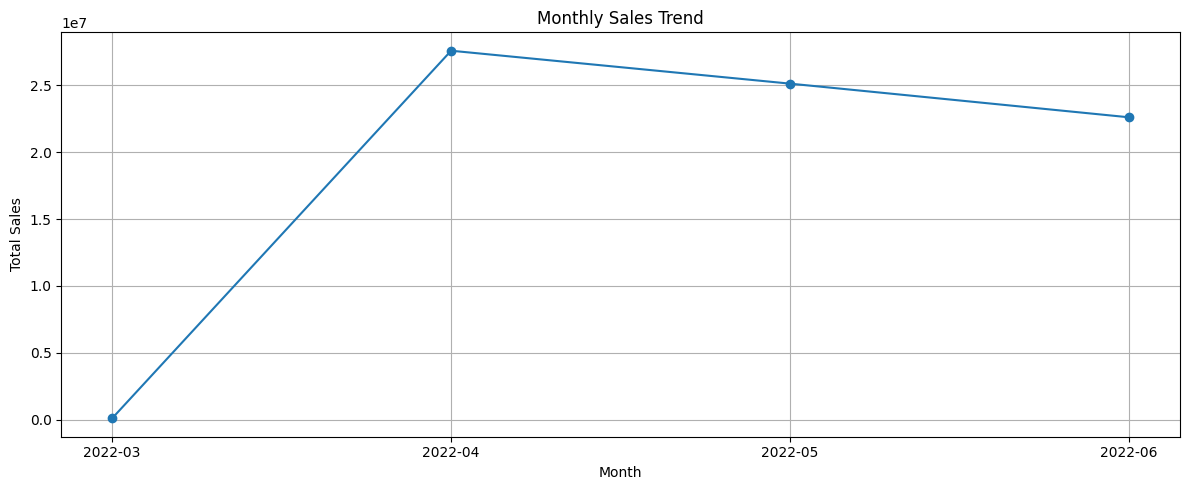

In [51]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_sales["month"],
    monthly_sales["total_sales"],
    marker = "o"    
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation = 0)
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

In [52]:
# Category-Wise Sales Analysis
query = """
select category,count(distinct order_id) as total_orders, 
coalesce(round(sum(amount),2),0) as total_sales
from sales
where category is not null
group by category
order by total_sales desc """
category_sales = pd.read_sql_query(query,conn)
category_sales

,category,total_orders,total_sales
0,Set,42962,37662424.0
1,kurta,41822,20452141.0
2,Western Dress,13430,10629096.0
3,Top,9429,5203733.0
4,Ethnic Dress,1041,760711.0
5,Blouse,814,434751.0
6,Bottom,370,140226.0
7,Saree,128,118509.0
8,Dupatta,2,915.0


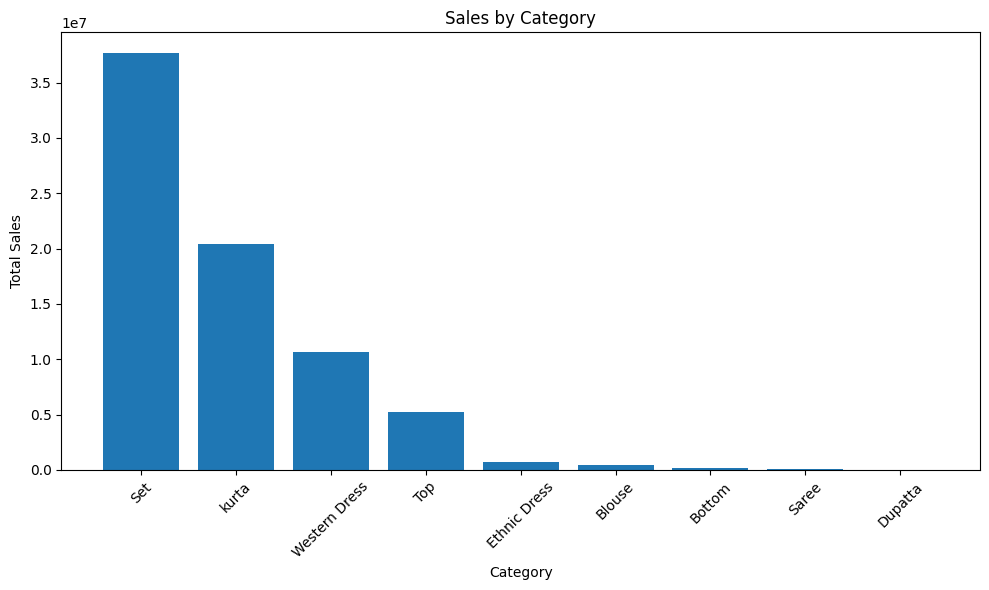

In [53]:
plt.figure(figsize = (10,6))
plt.bar(category_sales["category"],category_sales["total_sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()
plt.close()

In [54]:
# Top 10 Cities by Sales
query = """
select ship_city,count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
where ship_city is not null 
group by ship_city
order by total_sales desc limit 10"""
top_cities = pd.read_sql_query(query,conn)
top_cities

,ship_city,total_orders,total_sales
0,BENGALURU,9678,6670592.0
1,HYDERABAD,6696,4755742.0
2,MUMBAI,5223,3578211.0
3,NEW DELHI,4924,3484979.0
4,CHENNAI,4495,2969547.0
5,PUNE,3278,2256656.0
6,KOLKATA,2035,1360121.0
7,GURUGRAM,1642,1187675.0
8,THANE,1456,965211.0
9,LUCKNOW,1222,885623.0


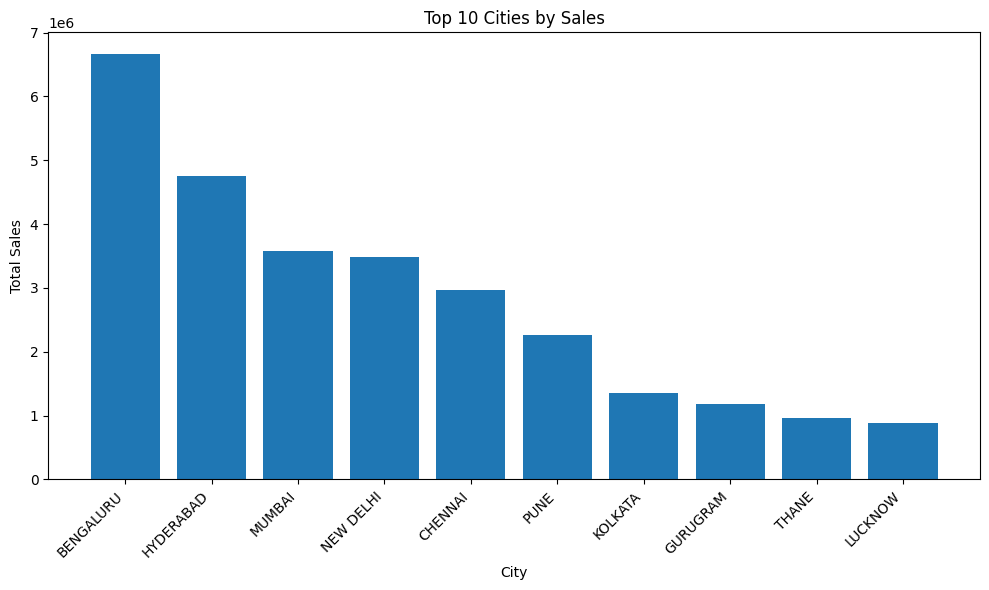

In [55]:
plt.figure(figsize=(10,6))
plt.bar(top_cities["ship_city"],top_cities["total_sales"])
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation = 45,ha = "right")
plt.tight_layout()
plt.show()
plt.close()

In [56]:
# Sales Chanel Analysis

query = """
select sales_channel, count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
where sales_channel is not null group by sales_channel order by total_sales desc """
channel_sales = pd.read_sql_query(query,conn)
channel_sales

,sales_channel,total_orders,total_sales
0,Amazon.in,108295,75402506.0
1,Non-Amazon,124,0.0


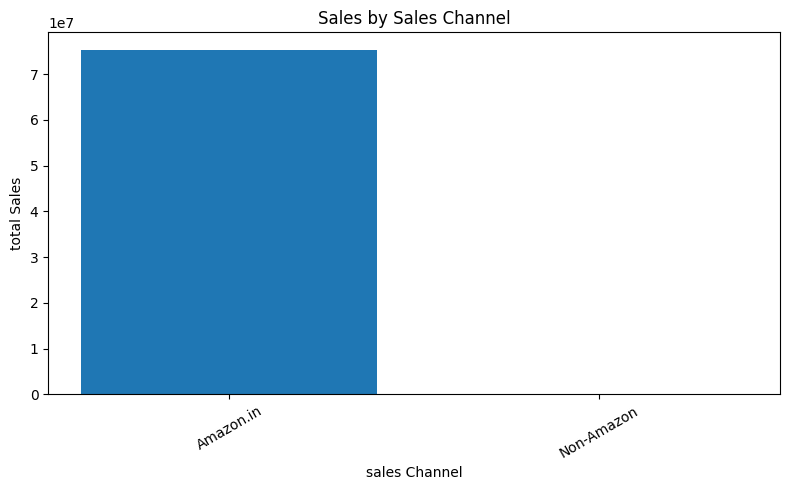

In [57]:
plt.figure(figsize =(8,5))
plt.bar(
    channel_sales["sales_channel"],
    channel_sales["total_sales"]
)
plt.title("Sales by Sales Channel")
plt.xlabel("sales Channel")
plt.ylabel("total Sales")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()
plt.close()

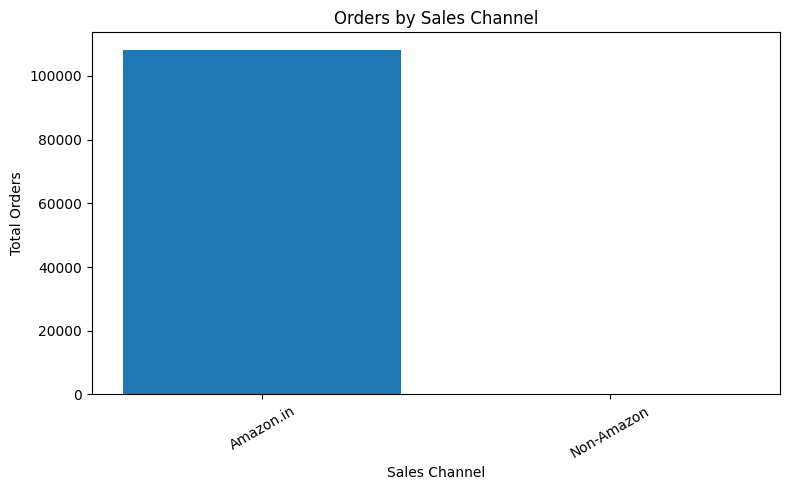

In [58]:
# sales Channel - Order Volume
plt.figure(figsize =(8,5))
plt.bar(
    channel_sales["sales_channel"],
    channel_sales["total_orders"]
)
plt.title("Orders by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Orders")
plt.xticks(rotation = 30 )
plt.tight_layout()
plt.show()
plt.close()

In [59]:
# Fulfilment Analysis
query = """
select fulfilment,count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales
from sales
where fulfilment is not null
group by fulfilment order by total_sales desc """
fulfilment_sales = pd.read_sql_query(query,conn)
fulfilment_sales

,fulfilment,total_orders,total_sales
0,Amazon,78425,54322151.0
1,Merchant,29994,21080355.0


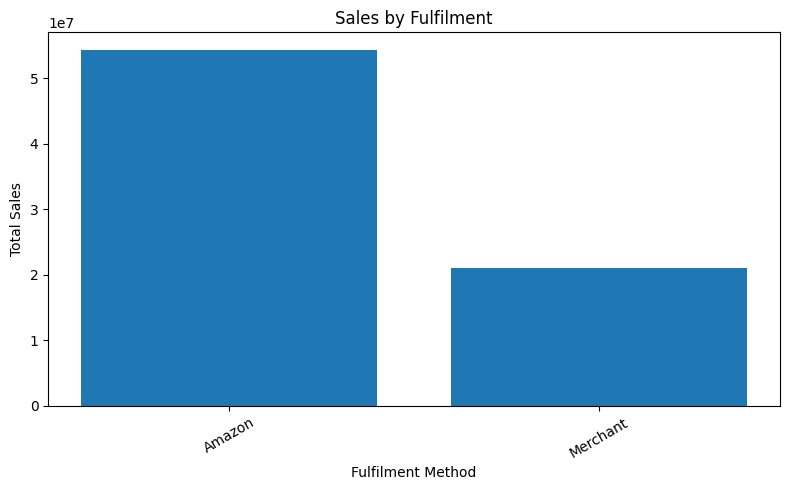

In [60]:
plt.figure(figsize=(8,5))
plt.bar(
    fulfilment_sales["fulfilment"],
    fulfilment_sales["total_sales"]
)
plt.title("Sales by Fulfilment")
plt.xlabel("Fulfilment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()
plt.close()

In [61]:
# State-Wise Sales Analysis
query = """ select ship_state,count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales from sales
where ship_state is not null group by ship_state
order by total_sales desc limit 10 """
sate_sales = pd.read_sql_query(query,conn)
state_sales

,ship_state,total_orders,total_sales
0,MAHARASHTRA,18930,12864511.0
1,KARNATAKA,14789,10153100.0
2,TELANGANA,9371,6642955.0
3,UTTAR PRADESH,8948,6494393.0
4,TAMIL NADU,9498,6241913.0
5,DELHI,5770,4080019.0
6,KERALA,5378,3618505.0
7,WEST BENGAL,5020,3357170.0
8,ANDHRA PRADESH,4396,3049151.0
9,HARYANA,3799,2791446.0


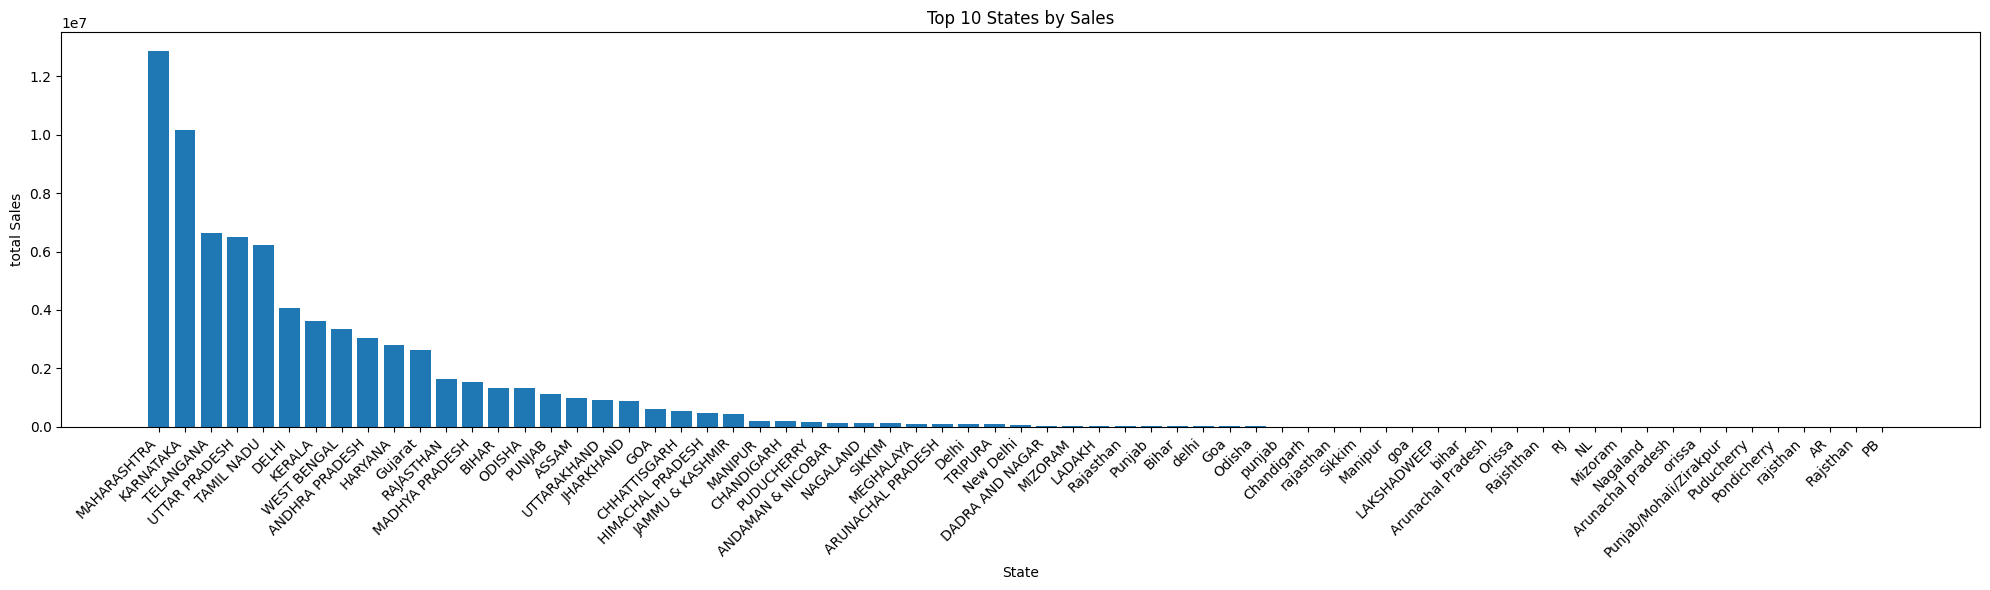

In [62]:
plt.figure(figsize= (20,6))
plt.bar(
    state_sales['ship_state'],
    state_sales['total_sales']
)
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("total Sales")
plt.xticks(rotation = 45,ha= "right")
plt.tight_layout()
plt.show()
plt.close()

In [63]:
# Courier Status Analyssi
query = """
select courier_status, count(distinct order_id) as total_orders from sales
where courier_status is not null
group by courier_status order by total_orders desc """
courier_status = pd.read_sql_query(query,conn)
courier_status

,courier_status,total_orders
0,Shipped,102232
1,Unshipped,6195


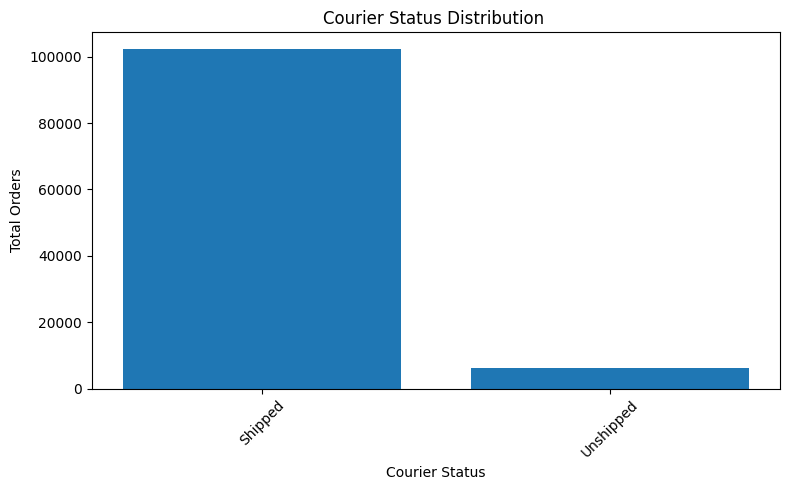

In [64]:
plt.figure(figsize = (8,5))
plt.bar(
    courier_status["courier_status"],
    courier_status["total_orders"]
)
plt.title("Courier Status Distribution ")
plt.xlabel("Courier Status")
plt.ylabel("Total Orders")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()
plt.close()

In [65]:
# Final KPI Summary 
query = """
select count(distinct order_id) as total_orders,
coalesce(round(sum(amount),2),0) as total_sales,
coalesce(round(avg(amount),2),0) as avg_order_value,
coalesce(sum(qty),0) as total_quantity from sales """
kpi_summary = pd.read_sql_query(query,conn)
kpi_summary

,total_orders,total_sales,avg_order_value,total_quantity
0,108419,75402506.0,649.78,116649


In [66]:
# Display Key KPIs
kpi = kpi_summary.iloc[0]
print("="*50)
print("AMAZON SALES - KEY PERFORMANCE INDICATIORS")
print("="*50)
print(f"Total Orders : {kpi['total_orders']:,}")
print(f"Total Sales : {kpi["total_sales"]:,.2f}")
print(f"Average Order Value : {kpi["avg_order_value"]:,.2f}")
print(f"Total Quantity : {kpi['total_quantity']:,}")
print("="*50)

AMAZON SALES - KEY PERFORMANCE INDICATIORS
Total Orders : 108,419.0
Total Sales : 75,402,506.00
Average Order Value : 649.78
Total Quantity : 116,649.0


In [69]:
unnamed_cols = [
    col for col in clean_df.columns
    if str(col).strip().lower().startswith("unnamed")   
]
print("Columns to remove :",unnamed_cols)
clean_df = clean_df.drop(columns = unnamed_cols, errors = "ignore")
print("Final Shape :", clean_df.shape)
print("Final columns :",clean_df.columns.tolist())

Columns to remove : ['unnamed:_22']
Final Shape : (116168, 23)
Final columns : ['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'style', 'sku', 'category', 'size', 'asin', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids', 'b2b', 'fulfilled_by']


In [70]:
# Expoert Final Cleaned Dataset for Poer Bi

POWERBI_FILE = "amazon_sales_cleaned.csv"
clean_df.to_csv(POWERBI_FILE,index = False)
print(f"Power BI file Create : {POWERBI_FILE}")
print(f"Rows : {len(clean_df):,}")
print(f"Columns : {len(clean_df.columns)}")

Power BI file Create : amazon_sales_cleaned.csv
Rows : 116,168
Columns : 23
